In [ ]:
# STAC + YOLO12m Semi-Supervised Learning
# Notebook 1: Implementation and Training

import os
import json
import random
import numpy as np
import torch
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import yaml
from datetime import datetime
import time
import shutil

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

print("✅ Environment setup complete")

✅ Environment setup complete


In [ ]:
# Install dependencies
!pip install ultralytics albumentations roboflow pycocotools matplotlib seaborn

import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")

Ultralytics version: 8.3.235


In [ ]:
!gdown --id 1DSOBWsiV_dExeLpxWl8uqetADJN1hnK1

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1DSOBWsiV_dExeLpxWl8uqetADJN1hnK1
From (redirected): https://drive.google.com/uc?id=1DSOBWsiV_dExeLpxWl8uqetADJN1hnK1&confirm=t&uuid=11570227-60ed-40f9-b184-cb7468ab386e
To: /content/Autism.v1i.coco.zip
100% 241M/241M [00:03<00:00, 75.7MB/s]


In [ ]:
!unzip -q "/content/Autism.v1i.coco.zip" -d "/content/dataset12"

In [ ]:
from pathlib import Path

# MAIN DATASET ROOT
DS = Path("/content/dataset12")

# Image folders - CORRECTED (no 'images' subfolder)
TRAIN_IMG = DS / "train"  # Images are directly here
VALID_IMG = DS / "valid"  # Images are directly here
TEST_IMG  = DS / "test"   # Images are directly here

# Annotation files
TRAIN_ANN = DS / "train" / "_annotations.coco.json"
VALID_ANN = DS / "valid" / "_annotations.coco.json"
TEST_ANN  = DS / "test"  / "_annotations.coco.json"

# SSL workspace (we will create labeled/unlabeled here)
SSL = DS / "ssl"
SSL.mkdir(parents=True, exist_ok=True)

# Verify everything
print("Train images:", len(list(TRAIN_IMG.glob('*.jpg'))))  # or *.png, *.jpeg
print("Valid images:", len(list(VALID_IMG.glob('*.jpg'))))
print("Test images:",  len(list(TEST_IMG.glob('*.jpg'))))

print("\nAnnotation files exist:")
print("Train:", TRAIN_ANN.exists())
print("Valid:", VALID_ANN.exists())
print("Test:",  TEST_ANN.exists())

Train images: 4048
Valid images: 1173
Test images: 645

Annotation files exist:
Train: True
Valid: True
Test: True


In [ ]:
import json, random, shutil
from collections import defaultdict

random.seed(42)

with open(TRAIN_ANN,"r") as f:
    coco = json.load(f)

imgs = coco["images"]
anns = coco["annotations"]
cats = coco["categories"]

ann_by_img = defaultdict(list)
for a in anns:
    ann_by_img[a["image_id"]].append(a)

img_ids = [x["id"] for x in imgs]
random.shuffle(img_ids)

total = len(img_ids)
n_label = int(0.10 * total)

labeled_ids = set(img_ids[:n_label])
unlabeled_ids = set(img_ids[n_label:])

def save_split_json(ids, out, include_ann=True):
    im_list = [im for im in imgs if im["id"] in ids]
    an_list = [a for a in anns if a["image_id"] in ids] if include_ann else []
    with open(out,"w") as f:
        json.dump({
            "images": im_list,
            "annotations": an_list,
            "categories": cats
        }, f)

save_split_json(labeled_ids, SSL/"labeled.json", True)
save_split_json(unlabeled_ids, SSL/"unlabeled.json", False)

# Copy images
def copy_imgs(ids, src, dst):
    dst.mkdir(parents=True, exist_ok=True)
    for im in imgs:
        if im["id"] in ids:
            shutil.copy2(src/im["file_name"], dst/im["file_name"])

copy_imgs(labeled_ids, TRAIN_IMG, SSL/"labeled/images")
copy_imgs(unlabeled_ids, TRAIN_IMG, SSL/"unlabeled/images")

print("Labeled:", len(labeled_ids), "Unlabeled:", len(unlabeled_ids))


Labeled: 404 Unlabeled: 3644


In [ ]:
# Step 6: Configuration Setup
import yaml
from datetime import datetime
import time

class Config:
    # Paths
    DATASET_ROOT = Path("/content/dataset12")
    SSL_ROOT = DATASET_ROOT / "ssl"

    # Model
    BACKBONE = "yolo12m"
    PRETRAINED_WEIGHTS = "yolo12m.pt"

    # Training
    EPOCHS = 50
    BATCH_SIZE = 16
    LEARNING_RATE = 1e-3
    IMG_SIZE = 640
    PATIENCE = 10

    # STAC Parameters
    PSEUDO_LABEL_THRESHOLD = 0.7
    CONF_THRESHOLD = 0.25
    IOU_THRESHOLD = 0.6

    # Augmentation
    AUGMENTATIONS = True

    # Output
    OUTPUT_DIR = Path("/content/output/yolo12m_stac")
    MODEL_SAVE_DIR = OUTPUT_DIR / "models"
    LOGS_DIR = OUTPUT_DIR / "logs"

    def __init__(self):
        self.MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
        self.LOGS_DIR.mkdir(parents=True, exist_ok=True)

config = Config()
print("✅ Configuration setup complete")

✅ Configuration setup complete


📊 Visualizing labeled data annotations...


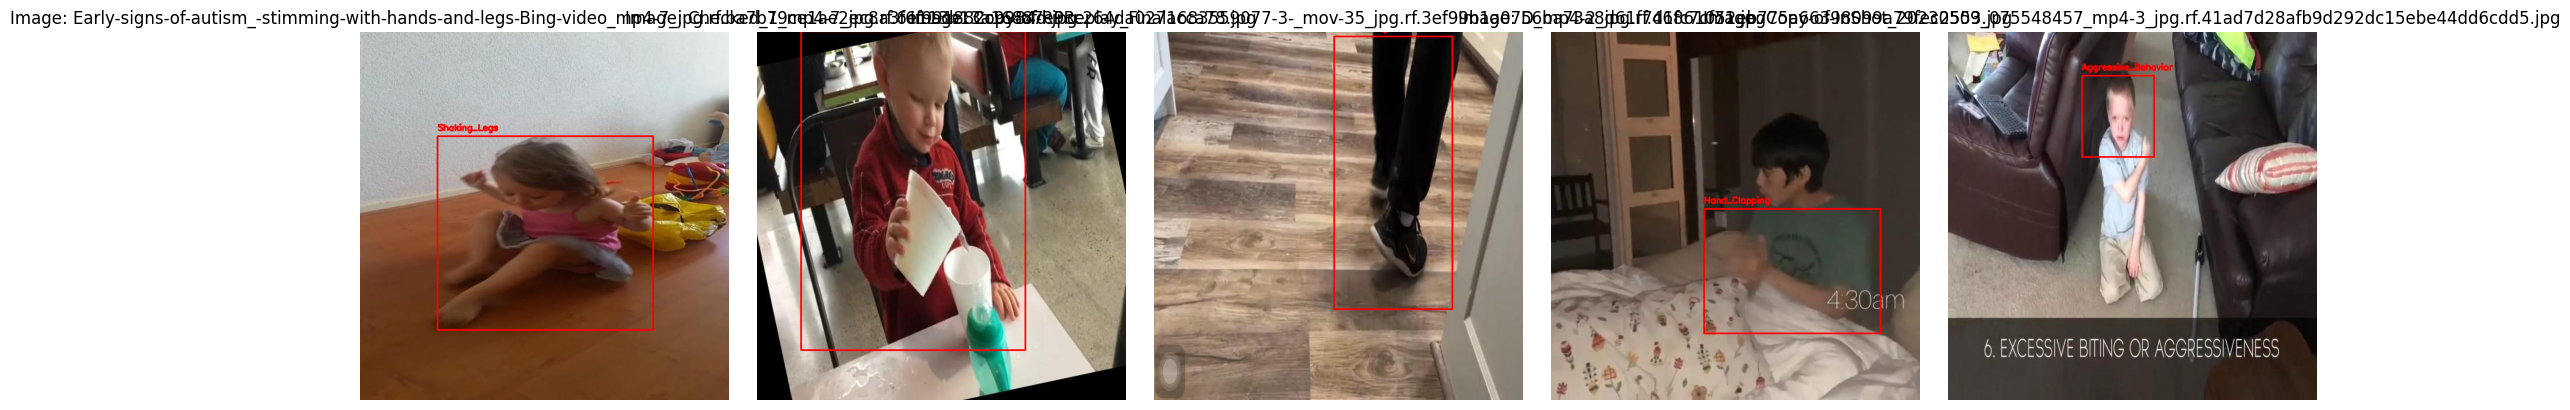

In [ ]:
# Step 8: Data Visualization - Verify Annotation Quality
import cv2
import matplotlib.pyplot as plt
import random

def visualize_annotations(annotation_path, image_dir, num_samples=5):
    """Visualize images with bounding boxes to verify annotation quality"""

    with open(annotation_path, 'r') as f:
        coco_data = json.load(f)

    images = coco_data['images']
    annotations = coco_data['annotations']
    categories = {cat['id']: cat['name'] for cat in coco_data['categories']}

    # Group annotations by image_id
    ann_by_image = {}
    for ann in annotations:
        image_id = ann['image_id']
        if image_id not in ann_by_image:
            ann_by_image[image_id] = []
        ann_by_image[image_id].append(ann)

    # Select random samples
    sample_images = random.sample(images, min(num_samples, len(images)))

    fig, axes = plt.subplots(1, num_samples, figsize=(20, 4))
    if num_samples == 1:
        axes = [axes]

    for idx, img_info in enumerate(sample_images):
        if idx >= num_samples:
            break

        # Load image
        img_path = image_dir / img_info['file_name']
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Draw bounding boxes
        if img_info['id'] in ann_by_image:
            for ann in ann_by_image[img_info['id']]:
                bbox = ann['bbox']  # [x, y, width, height]
                category_id = ann['category_id']

                # Convert COCO bbox to [x1, y1, x2, y2]
                x1, y1, w, h = bbox
                x2, y2 = x1 + w, y1 + h

                # Draw rectangle
                cv2.rectangle(image, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)

                # Add label
                label = categories.get(category_id, 'Unknown')
                cv2.putText(image, label, (int(x1), int(y1-10)),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        axes[idx].imshow(image)
        axes[idx].set_title(f"Image: {img_info['file_name']}")
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

print("📊 Visualizing labeled data annotations...")
visualize_annotations(config.SSL_ROOT / "labeled.json",
                     config.SSL_ROOT / "labeled/images",
                     num_samples=5)

In [ ]:
# Step 9: Convert COCO to YOLO Format
def create_yolo_dataset_structure():
    """Convert COCO format to YOLO format for training"""

    yolo_dir = config.DATASET_ROOT / "yolo_format"
    yolo_dir.mkdir(parents=True, exist_ok=True)

    splits = ['labeled', 'unlabeled', 'valid', 'test']

    for split in splits:
        # Create directories
        img_dir = yolo_dir / split / 'images'
        label_dir = yolo_dir / split / 'labels'
        img_dir.mkdir(parents=True, exist_ok=True)
        label_dir.mkdir(parents=True, exist_ok=True)

        if split in ['labeled', 'unlabeled']:
            # SSL splits
            ann_file = config.SSL_ROOT / f"{split}.json"
            src_img_dir = config.SSL_ROOT / split / "images"
        else:
            # Original splits
            ann_file = config.DATASET_ROOT / split / "_annotations.coco.json"
            src_img_dir = config.DATASET_ROOT / split

        if split == 'unlabeled':
            # For unlabeled, just copy images
            for img_file in src_img_dir.glob('*.jpg'):
                shutil.copy2(img_file, img_dir / img_file.name)
            continue

        # Load COCO annotations
        with open(ann_file, 'r') as f:
            coco_data = json.load(f)

        # Create mapping
        images = {img['id']: img for img in coco_data['images']}
        categories = {cat['id']: idx for idx, cat in enumerate(coco_data['categories'])}

        # Group annotations by image_id
        ann_by_image = {}
        for ann in coco_data['annotations']:
            image_id = ann['image_id']
            if image_id not in ann_by_image:
                ann_by_image[image_id] = []
            ann_by_image[image_id].append(ann)

        # Convert to YOLO format and copy images
        for img_id, img_info in images.items():
            # Copy image
            src_img_path = src_img_dir / img_info['file_name']
            dst_img_path = img_dir / img_info['file_name']
            shutil.copy2(src_img_path, dst_img_path)

            # Create label file
            if img_id in ann_by_image:
                label_file = label_dir / f"{Path(img_info['file_name']).stem}.txt"
                with open(label_file, 'w') as f:
                    for ann in ann_by_image[img_id]:
                        bbox = ann['bbox']
                        category_id = categories[ann['category_id']]

                        # Convert COCO bbox to YOLO format [x_center, y_center, width, height]
                        x_center = (bbox[0] + bbox[2] / 2) / img_info['width']
                        y_center = (bbox[1] + bbox[3] / 2) / img_info['height']
                        width = bbox[2] / img_info['width']
                        height = bbox[3] / img_info['height']

                        f.write(f"{category_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

    print("✅ YOLO dataset structure created")

create_yolo_dataset_structure()

✅ YOLO dataset structure created


In [ ]:
# Step 10: Create Dataset YAML File
def create_dataset_yaml():
    """Create dataset YAML file for YOLO training"""

    # Get class names from labeled annotations
    with open(config.SSL_ROOT / "labeled.json", 'r') as f:
        coco_data = json.load(f)

    class_names = [cat['name'] for cat in coco_data['categories']]

    dataset_yaml = {
        'path': str(config.DATASET_ROOT / "yolo_format"),
        'train': 'labeled/images',
        'val': 'valid/images',
        'test': 'test/images',
        'names': class_names,
        'nc': len(class_names)
    }

    yaml_path = config.DATASET_ROOT / "dataset.yaml"
    with open(yaml_path, 'w') as f:
        yaml.dump(dataset_yaml, f, default_flow_style=False)

    print(f"✅ Dataset YAML created with {len(class_names)} classes:")
    for i, name in enumerate(class_names):
        print(f"  {i}: {name}")

    return yaml_path

dataset_yaml_path = create_dataset_yaml()
config.DATASET_YAML = dataset_yaml_path

✅ Dataset YAML created with 17 classes:
  0: Behaviors
  1: Aggressive_Behavior
  2: Avoid_Eye_Contact
  3: Covering_Ears
  4: Finger_Bitting
  5: Finger_Flicking
  6: Hand_Clapping
  7: Hand_Flapping
  8: Head_Banging
  9: Holding_Item
  10: Jumping
  11: SIB_Bitting
  12: Shaking_Legs
  13: Toe_Walking
  14: Tpot_Stimming
  15: Twirling
  16: Weird_Expression


In [ ]:
import torch, yaml, shutil
from ultralytics import YOLO


class STACTrainer:
    def __init__(self, config):
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"🚀 Using device: {self.device}")

    # -------------------------------
    # PHASE 1 – TEACHER TRAINING
    # -------------------------------
    def train_teacher(self):
        print("\n📚 Phase 1: Training teacher model on labeled data...")

        teacher = YOLO(self.config.PRETRAINED_WEIGHTS)

        results_phase1 = teacher.train(
            data=str(self.config.DATASET_YAML),
            epochs=50,
            imgsz=self.config.IMG_SIZE,
            batch=self.config.BATCH_SIZE,
            lr0=self.config.LEARNING_RATE,
            patience=self.config.PATIENCE,
            augment=self.config.AUGMENTATIONS,
            project=str(self.config.OUTPUT_DIR),
            name="yolo12m_phase1",
            exist_ok=True,
            seed=42
        )

        # path to teacher last.pt
        self.teacher_weights = f"{self.config.OUTPUT_DIR}/yolo12m_phase1/weights/last.pt"
        print(f"✅ Phase-1 Completed. Teacher weights saved at:\n{self.teacher_weights}")

        return self.teacher_weights, results_phase1

    # ---------------------------------------------------------
    # Generate pseudo-labels using teacher
    # ---------------------------------------------------------
    def generate_pseudo_labels(self, teacher_model, confidence_threshold=0.7):
        print("\n🎯 Generating pseudo-labels...")

        unlabeled_dir = self.config.DATASET_ROOT / "yolo_format" / "unlabeled" / "images"
        pseudo_labels_dir = self.config.DATASET_ROOT / "yolo_format" / "pseudo_labels"

        pseudo_labels_dir.mkdir(parents=True, exist_ok=True)

        unlabeled_images = list(unlabeled_dir.glob("*.jpg"))
        pseudo_label_count = 0

        for img_path in unlabeled_images:
            results = teacher_model.predict(
                source=str(img_path),
                conf=confidence_threshold,
                iou=self.config.IOU_THRESHOLD,
                verbose=False
            )

            lbl_path = pseudo_labels_dir / f"{img_path.stem}.txt"

            with open(lbl_path, "w") as f:
                for result in results:
                    if result.boxes is not None:
                        for box in result.boxes:
                            cls = int(box.cls.item())
                            x, y, w, h = box.xywhn[0].tolist()
                            f.write(f"{cls} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")
                            pseudo_label_count += 1

        print(f"✅ Pseudo-labels generated for {len(unlabeled_images)} images.")
        return pseudo_labels_dir

    # ---------------------------------------------------------
    # Combine real + pseudo labeled datasets
    # ---------------------------------------------------------
    def combine_datasets(self, pseudo_labels_dir):
        print("🔗 Combining labeled + pseudo-labeled datasets...")

        combined_dir = self.config.DATASET_ROOT / "yolo_format" / "combined"
        images_out = combined_dir / "images"
        labels_out = combined_dir / "labels"

        images_out.mkdir(parents=True, exist_ok=True)
        labels_out.mkdir(parents=True, exist_ok=True)

        # Copy labeled data
        labeled_img_dir = self.config.DATASET_ROOT / "yolo_format" / "labeled" / "images"
        labeled_lbl_dir = self.config.DATASET_ROOT / "yolo_format" / "labeled" / "labels"

        for img in labeled_img_dir.glob("*.jpg"):
            shutil.copy2(img, images_out / img.name)
        for lbl in labeled_lbl_dir.glob("*.txt"):
            shutil.copy2(lbl, labels_out / lbl.name)

        # Copy unlabeled images + pseudo labels
        unlabeled_dir = self.config.DATASET_ROOT / "yolo_format" / "unlabeled" / "images"

        for img in unlabeled_dir.glob("*.jpg"):
            shutil.copy2(img, images_out / img.name)

            pseudo_file = pseudo_labels_dir / f"{img.stem}.txt"
            if pseudo_file.exists():
                shutil.copy2(pseudo_file, labels_out / f"{img.stem}.txt")

        print("✅ Combined dataset ready.")
        return combined_dir

    # ---------------------------------------------------------
    # PHASE 2 – STUDENT TRAINING + RESUME SUPPORT
    # ---------------------------------------------------------
    def train_student(self, resume_checkpoint=None):
        print("\n🎯 Phase 2: Training student model...")

        # Must have Phase-1 done
        if not hasattr(self, "teacher_weights"):
            raise ValueError("❌ teacher_weights missing. Run train_teacher() first.")

        # Load teacher
        teacher = YOLO(self.teacher_weights)

        # STEP 1: pseudo labels
        pseudo_labels_dir = self.generate_pseudo_labels(
            teacher_model=teacher,
            confidence_threshold=self.config.PSEUDO_LABEL_THRESHOLD
        )

        # STEP 2: combine datasets
        combined_dir = self.combine_datasets(pseudo_labels_dir)

        # STEP 3: prepare YAML
        combined_yaml_path = self.config.DATASET_ROOT / "combined_dataset.yaml"

        yaml_dict = {
            "path": str(self.config.DATASET_ROOT / "yolo_format"),
            "train": "combined/images",
            "val": "valid/images",
            "test": "test/images",
            "names": teacher.model.names,
            "nc": len(teacher.model.names)
        }

        with open(combined_yaml_path, "w") as f:
            yaml.dump(yaml_dict, f)

        # STEP 4: load student model
        if resume_checkpoint:
            print(f"🔄 Resuming Phase-2 from: {resume_checkpoint}")
            student = YOLO(resume_checkpoint)
            resume_flag = True
        else:
            student = YOLO(self.config.PRETRAINED_WEIGHTS)
            resume_flag = False

        # STEP 5: Train student (auto checkpoint)
        results_phase2 = student.train(
            data=str(combined_yaml_path),
            epochs=50,
            imgsz=self.config.IMG_SIZE,
            batch=self.config.BATCH_SIZE,
            lr0=self.config.LEARNING_RATE,
            patience=self.config.PATIENCE,
            augment=self.config.AUGMENTATIONS,
            project=str(self.config.OUTPUT_DIR),
            name="yolo12m_stac_final",
            exist_ok=True,
            resume=resume_flag,
            seed=42
        )

        print("💾 Phase-2 completed. Checkpoints saved automatically.")
        return student, results_phase2


In [ ]:
# Phase-1 (Teacher Training)
stac = STACTrainer(config)

print("🏁 Running Phase-1")
teacher_weights, phase1_results = stac.train_teacher()


🚀 Using device: cuda
🏁 Running Phase-1

📚 Phase 1: Training teacher model on labeled data...
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset12/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo12m_phase1, nbs=64, nms=False, opset=No

run this

In [ ]:
stac = STACTrainer(config)
stac.teacher_weights = "/content/output/yolo12m_stac/best.pt"

🚀 Using device: cuda


In [ ]:
!zip -r /content/yolo12m_phase1.zip /content/output/yolo12m_stac/yolo12m_phase1
from google.colab import files
files.download('/content/yolo12m_phase1.zip')

  adding: content/output/yolo12m_stac/yolo12m_phase1/ (stored 0%)
  adding: content/output/yolo12m_stac/yolo12m_phase1/val_batch1_labels.jpg (deflated 8%)
  adding: content/output/yolo12m_stac/yolo12m_phase1/BoxR_curve.png (deflated 4%)
  adding: content/output/yolo12m_stac/yolo12m_phase1/train_batch1040.jpg (deflated 7%)
  adding: content/output/yolo12m_stac/yolo12m_phase1/train_batch1042.jpg (deflated 10%)
  adding: content/output/yolo12m_stac/yolo12m_phase1/train_batch2.jpg (deflated 2%)
  adding: content/output/yolo12m_stac/yolo12m_phase1/train_batch1041.jpg (deflated 8%)
  adding: content/output/yolo12m_stac/yolo12m_phase1/val_batch2_labels.jpg (deflated 9%)
  adding: content/output/yolo12m_stac/yolo12m_phase1/val_batch1_pred.jpg (deflated 7%)
  adding: content/output/yolo12m_stac/yolo12m_phase1/BoxPR_curve.png (deflated 7%)
  adding: content/output/yolo12m_stac/yolo12m_phase1/confusion_matrix.png (deflated 14%)
  adding: content/output/yolo12m_stac/yolo12m_phase1/confusion_matrix

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
student_model, phase2_results = stac.train_student()


🎯 Phase 2: Training student model...

🎯 Generating pseudo-labels...
✅ Pseudo-labels generated for 3644 images.
🔗 Combining labeled + pseudo-labeled datasets...
✅ Combined dataset ready.
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset12/combined_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo

KeyboardInterrupt: 

In [ ]:
!zip -r /content/yolo12m_stac_final.zip /content/output/yolo12m_stac/yolo12m_stac_final
from google.colab import files
files.download('/content/yolo12m_stac_final.zip')

  adding: content/output/yolo12m_stac/yolo12m_stac_final/ (stored 0%)
  adding: content/output/yolo12m_stac/yolo12m_stac_final/val_batch1_labels.jpg (deflated 8%)
  adding: content/output/yolo12m_stac/yolo12m_stac_final/BoxR_curve.png (deflated 4%)
  adding: content/output/yolo12m_stac/yolo12m_stac_final/train_batch10121.jpg (deflated 8%)
  adding: content/output/yolo12m_stac/yolo12m_stac_final/train_batch10122.jpg (deflated 7%)
  adding: content/output/yolo12m_stac/yolo12m_stac_final/train_batch2.jpg (deflated 3%)
  adding: content/output/yolo12m_stac/yolo12m_stac_final/val_batch2_labels.jpg (deflated 9%)
  adding: content/output/yolo12m_stac/yolo12m_stac_final/val_batch1_pred.jpg (deflated 9%)
  adding: content/output/yolo12m_stac/yolo12m_stac_final/BoxPR_curve.png (deflated 7%)
  adding: content/output/yolo12m_stac/yolo12m_stac_final/confusion_matrix.png (deflated 15%)
  adding: content/output/yolo12m_stac/yolo12m_stac_final/confusion_matrix_normalized.png (deflated 12%)
  adding: c

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
student_model, phase2_results = stac.train_student(resume_checkpoint="/content/output/yolo12m_stac/yolo12m_stac_final/weights/last.pt")


🎯 Phase 2: Training student model...

🎯 Generating pseudo-labels...
✅ Pseudo-labels generated for 3644 images.
🔗 Combining labeled + pseudo-labeled datasets...
✅ Combined dataset ready.
🔄 Resuming Phase-2 from: /content/output/yolo12m_stac/yolo12m_stac_final/weights/last.pt
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset12/combined_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_widt

KeyboardInterrupt: 

In [ ]:
student_model, phase2_results = stac.train_student(resume_checkpoint="/content/output/yolo12m_stac/yolo12m_stac_final/weights/last.pt")


🎯 Phase 2: Training student model...

🎯 Generating pseudo-labels...
✅ Pseudo-labels generated for 3644 images.
🔗 Combining labeled + pseudo-labeled datasets...
✅ Combined dataset ready.
🔄 Resuming Phase-2 from: /content/output/yolo12m_stac/yolo12m_stac_final/weights/last.pt
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset12/combined_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_widt

In [ ]:
import time
from ultralytics import YOLO # Ensure YOLO is imported

# Step 13: Model Evaluation
def evaluate_model(model, dataset_yaml_path, config, split='val'): # Changed default split to 'val'
    """Comprehensive model evaluation"""
    print(f"📊 Evaluating model on {split} set...")

    start_time = time.time()

    # Run validation
    metrics = model.val(
        data=str(dataset_yaml_path),
        split=split, # This will now correctly use 'val'
        conf=config.CONF_THRESHOLD,
        iou=config.IOU_THRESHOLD,
        verbose=False
    )

    inference_time = time.time() - start_time

    # Calculate FPS
    # Use the correct split name ('val') for directory lookup
    split_images_dir = config.DATASET_ROOT / "yolo_format" / split / "images"
    if split_images_dir.exists():
        num_images = len(list(split_images_dir.glob("*.jpg")))
    else:
        # Fallback: if directory doesn't exist, use default or estimate
        num_images = 100  # Default estimate or adjust as needed
        print(f"⚠️  {split}/images directory not found, using {num_images} as image count")

    fps = num_images / inference_time if inference_time > 0 else 0

    print(f"⏱️  Inference Speed: {fps:.2f} FPS")
    print(f"📈 mAP@0.5: {metrics.box.map50:.4f}")
    print(f"📈 mAP@0.5:0.95: {metrics.box.map:.4f}")
    print(f"🎯 Precision: {metrics.box.p.mean().item():.4f}") # Added .mean().item()
    print(f"🔍 Recall: {metrics.box.r.mean().item():.4f}")    # Added .mean().item()

    return {
        'mAP@0.5': metrics.box.map50.item(), # Added .item()
        'mAP@0.5:0.95': metrics.box.map.item(), # Added .item()
        'precision': metrics.box.p.mean().item(), # Added .mean().item()
        'recall': metrics.box.r.mean().item(), # Added .mean().item()
        'fps': fps,
        'inference_time': inference_time,
        'num_images': num_images
    }

# Assuming `config`, `dataset_yaml_path`, `teacher_weights`, and `student_model`
# are defined in previous executed cells.

print("🔬 Evaluating Teacher Model (Phase 1)...")
teacher_model = YOLO(stac.teacher_weights) # Load the teacher model explicitly
teacher_metrics = evaluate_model(teacher_model, dataset_yaml_path, config, split='val') # Changed split to 'val'

print("\n🔬 Evaluating Student Model (STAC Final)...")
student_model_path = config.OUTPUT_DIR / "yolo12m_stac_final" / "weights" / "best.pt" # Corrected path
student_model = YOLO(student_model_path) # Load student model explicitly
student_metrics = evaluate_model(student_model, dataset_yaml_path, config, split='val') # Changed split to 'val'

# Optional: Print comparison
print("\n" + "="*50)
print("📊 MODEL COMPARISON")
print("="*50)
print(f"Metric              | Teacher     | Student     | Improvement")
print("-"*50)
print(f"mAP@0.5             | {teacher_metrics['mAP@0.5']:.4f}      | {student_metrics['mAP@0.5']:.4f}      | {student_metrics['mAP@0.5'] - teacher_metrics['mAP@0.5']:+.4f}")
print(f"mAP@0.5:0.95        | {teacher_metrics['mAP@0.5:0.95']:.4f}      | {student_metrics['mAP@0.5:0.95']:.4f}      | {student_metrics['mAP@0.5:0.95'] - teacher_metrics['mAP@0.5:0.95']:+.4f}")
print(f"Precision           | {teacher_metrics['precision']:.4f}      | {student_metrics['precision']:.4f}      | {student_metrics['precision'] - teacher_metrics['precision']:+.4f}")
print(f"Recall              | {teacher_metrics['recall']:.4f}      | {student_metrics['recall']:.4f}      | {student_metrics['recall'] - teacher_metrics['recall']:+.4f}")
print(f"FPS                 | {teacher_metrics['fps']:.2f}      | {student_metrics['fps']:.2f}      | {student_metrics['fps'] - teacher_metrics['fps']:+.2f}")

🔬 Evaluating Teacher Model (Phase 1)...
📊 Evaluating model on val set...
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12m summary (fused): 169 layers, 20,118,019 parameters, 0 gradients, 67.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1269.2±452.5 MB/s, size: 37.6 KB)
val: Scanning /content/dataset12/yolo_format/valid/labels.cache... 1173 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1173/1173 1.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 74/74 1.7it/s 44.2s
                   all       1173       1191       0.73      0.672      0.728      0.451
Speed: 1.4ms preprocess, 33.2ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/detect/val2
⚠️  val/images directory not found, using 100 as image count
⏱️  Inference Speed: 2.04 FPS
📈 mAP@0.5: 0.7283
📈 mAP@0.5:0.95: 0.4513
🎯 Precision: 0.7298
🔍 Recall: 0.6718

🔬 Evaluating 

In [ ]:
# Step 17: Save Final Model
def save_final_model(model, metrics):
    """Save the final trained model"""

    model_path = config.MODEL_SAVE_DIR / f"yolo12m_stac_final.pt"
    model.save(model_path)

    print(f"✅ Final model saved to: {model_path}")

save_final_model(student_model, student_metrics)

✅ Final model saved to: /content/output/yolo12m_stac/models/yolo12m_stac_final.pt


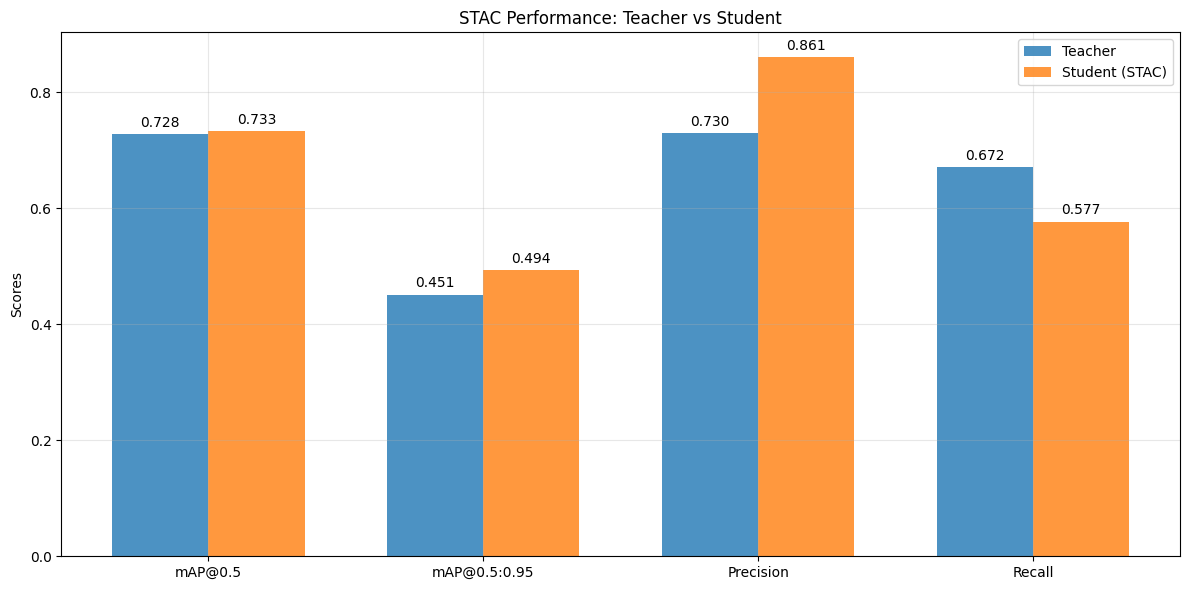

In [ ]:
# Step 14: Results Visualization and Comparison
import numpy as np

def plot_comparison(teacher_metrics, student_metrics):
    """Plot comparison between teacher and student metrics"""

    metrics_names = ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall']
    teacher_scores = [teacher_metrics['mAP@0.5'], teacher_metrics['mAP@0.5:0.95'],
                     teacher_metrics['precision'], teacher_metrics['recall']]
    student_scores = [student_metrics['mAP@0.5'], student_metrics['mAP@0.5:0.95'],
                     student_metrics['precision'], student_metrics['recall']]

    x = np.arange(len(metrics_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width/2, teacher_scores, width, label='Teacher', alpha=0.8)
    rects2 = ax.bar(x + width/2, student_scores, width, label='Student (STAC)', alpha=0.8)

    ax.set_ylabel('Scores')
    ax.set_title('STAC Performance: Teacher vs Student')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_names)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add value labels on bars
    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                   xy=(rect.get_x() + rect.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

plot_comparison(teacher_metrics, student_metrics)

In [ ]:
# Step 15: Save Final Results
def save_final_results(teacher_metrics, student_metrics):
    """Save final results to a markdown file"""

    results_md = f"""
# STAC + YOLO12m Results

## Training Configuration
- **Backbone**: YOLO12m
- **Labeled Data**: 404 images
- **Unlabeled Data**:3644 images
- **Epochs**: 50 (Phase 1) + 50 (Phase 2)
- **Batch Size**: {config.BATCH_SIZE}
- **Learning Rate**: {config.LEARNING_RATE}
- **Pseudo-label Threshold**: {config.PSEUDO_LABEL_THRESHOLD}

## Performance Metrics

| Model | mAP@0.5 | mAP@0.5:0.95 | Precision | Recall | FPS |
|-------|----------|---------------|-----------|--------|-----|
| Teacher | {teacher_metrics['mAP@0.5']:.4f} | {teacher_metrics['mAP@0.5:0.95']:.4f} | {teacher_metrics['precision']:.4f} | {teacher_metrics['recall']:.4f} | {teacher_metrics['fps']:.2f} |
| Student (STAC) | {student_metrics['mAP@0.5']:.4f} | {student_metrics['mAP@0.5:0.95']:.4f} | {student_metrics['precision']:.4f} | {student_metrics['recall']:.4f} | {student_metrics['fps']:.2f} |

## Improvement
- **mAP@0.5 Improvement**: {student_metrics['mAP@0.5'] - teacher_metrics['mAP@0.5']:.4f}
- **mAP@0.5:0.95 Improvement**: {student_metrics['mAP@0.5:0.95'] - teacher_metrics['mAP@0.5:0.95']:.4f}

*Results generated on: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}*
"""

    results_path = config.OUTPUT_DIR / "results.md"
    with open(results_path, 'w') as f:
        f.write(results_md)

    print(f"✅ Results saved to: {results_path}")
    print(results_md)

save_final_results(teacher_metrics, student_metrics)


✅ Results saved to: /content/output/yolo12m_stac/results.md

# STAC + YOLO12m Results

## Training Configuration
- **Backbone**: YOLO12m
- **Labeled Data**: 404 images
- **Unlabeled Data**:3644 images
- **Epochs**: 50 (Phase 1) + 50 (Phase 2)
- **Batch Size**: 16
- **Learning Rate**: 0.001
- **Pseudo-label Threshold**: 0.7

## Performance Metrics

| Model | mAP@0.5 | mAP@0.5:0.95 | Precision | Recall | FPS |
|-------|----------|---------------|-----------|--------|-----|
| Teacher | 0.7283 | 0.4513 | 0.7298 | 0.6718 | 2.04 |
| Student (STAC) | 0.7332 | 0.4940 | 0.8605 | 0.5772 | 2.07 |

## Improvement
- **mAP@0.5 Improvement**: 0.0048
- **mAP@0.5:0.95 Improvement**: 0.0427

*Results generated on: 2025-12-06 18:29:36*



🖼️ Visualizing BEST detection results...
--------------------------------------------------
🔍 Finding images with best detections (min 2 detections, confidence ≥ 0.6)...
⚠️ No images found with 2+ detections at confidence 0.6
🔄 Falling back to random sampling...


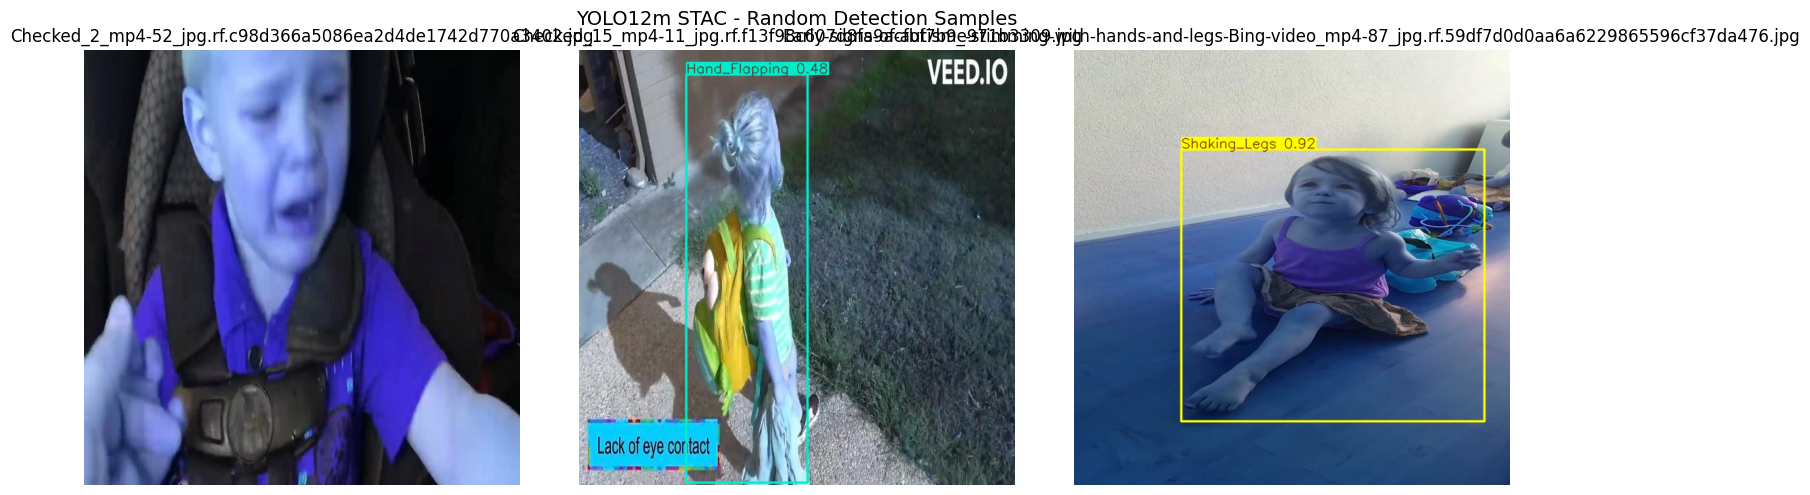


🎨 Visualizing DIVERSE detection scenarios...
--------------------------------------------------
🎨 Selecting diverse detection scenarios...


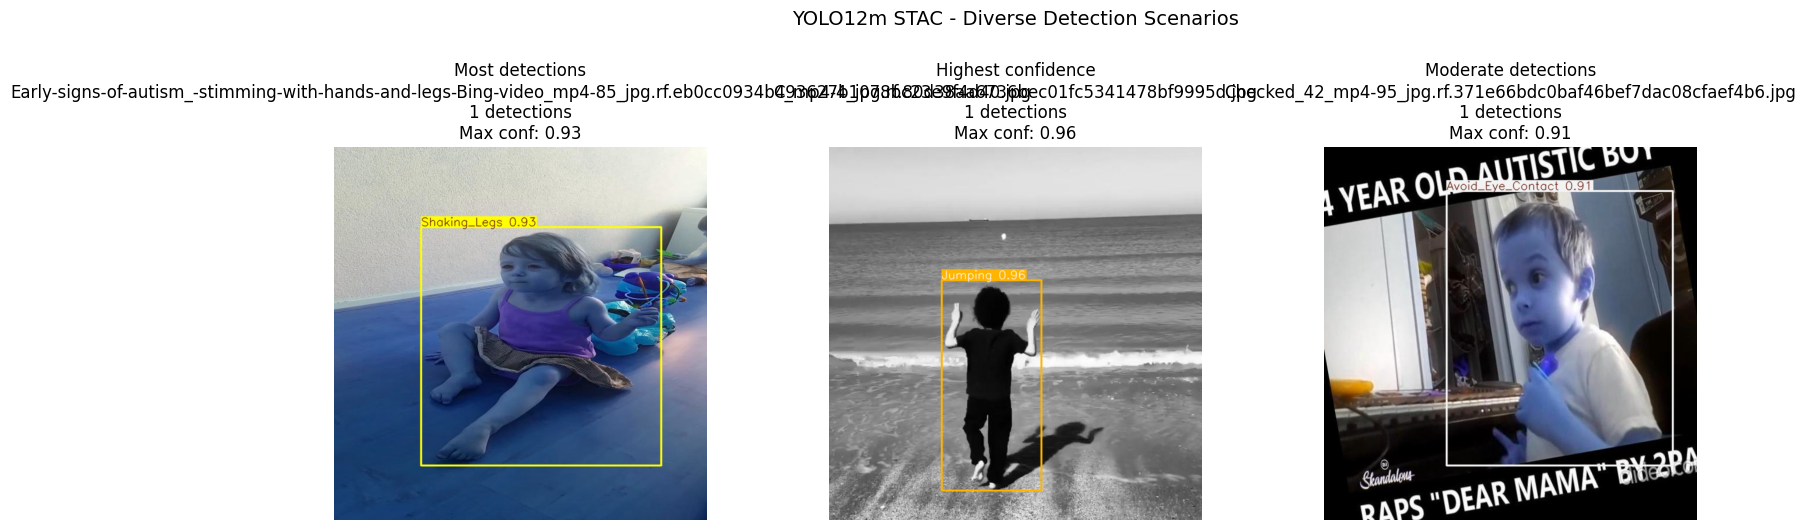


📊 Diverse Scenarios Analysis:
1. Most detections:
   Image: Early-signs-of-autism_-stimming-with-hands-and-legs-Bing-video_mp4-85_jpg.rf.eb0cc0934b493627b1078bc23e9f4d40.jpg
   Detections: 1
   Avg confidence: 0.929
   Max confidence: 0.929
2. Highest confidence:
   Image: C_mp4-4_jpg.rf.80d38aa6736bec01fc5341478bf9995d.jpg
   Detections: 1
   Avg confidence: 0.956
   Max confidence: 0.956
3. Moderate detections:
   Image: Checked_42_mp4-95_jpg.rf.371e66bdc0baf46bef7dac08cfaef4b6.jpg
   Detections: 1
   Avg confidence: 0.909
   Max confidence: 0.909

🔄 Comparing Teacher vs Student on same images...
--------------------------------------------------

📊 Image 1: A_mp4-204_jpg.rf.66c779bb2f0f56fb8ba4af06ef747047.jpg


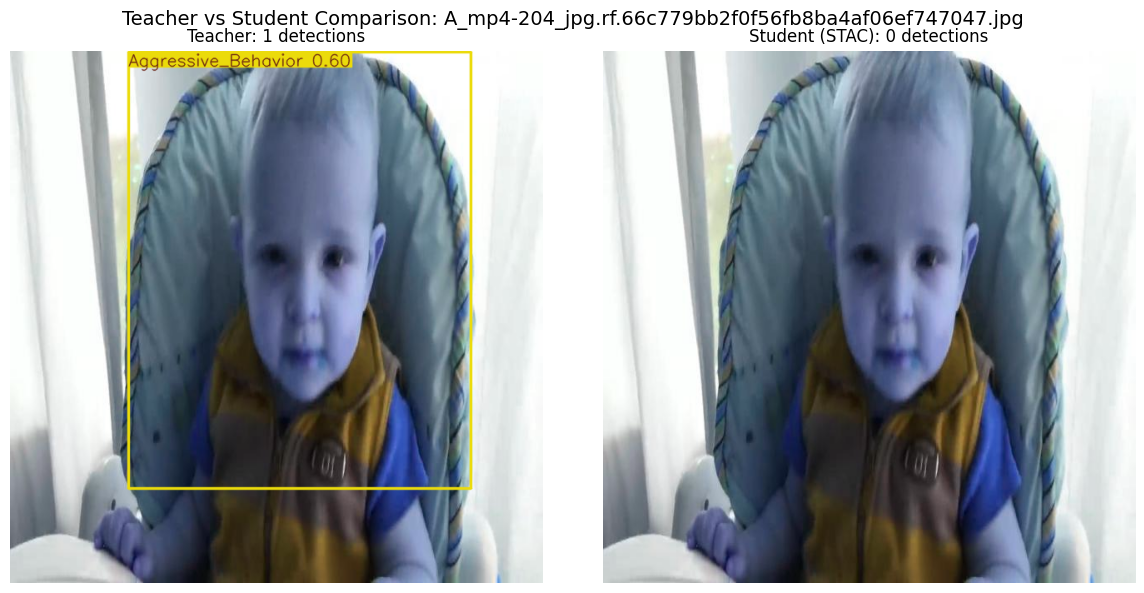

   Teacher: 1 detections, avg conf: 0.601
   Student: 0 detections, avg conf: nan

📊 Image 2: Checked_31_mp4-42_jpg.rf.2f288fba57ddeaeb31de6fa4396e7796.jpg


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


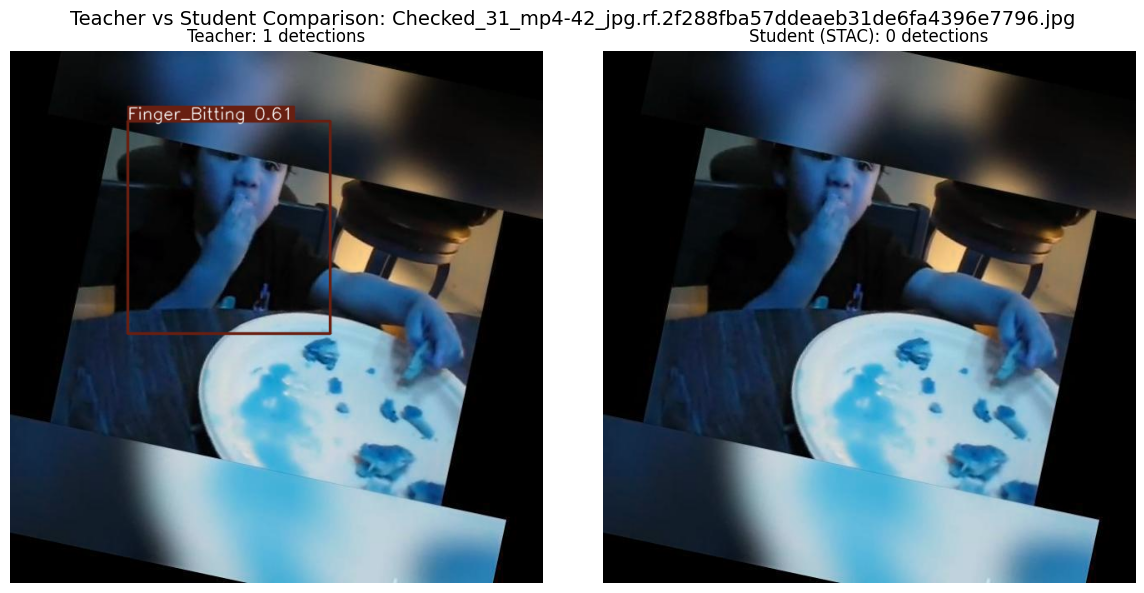

   Teacher: 1 detections, avg conf: 0.615
   Student: 0 detections, avg conf: nan


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Step 16: Qualitative Results Visualization - BEST DETECTIONS
def visualize_best_detections(model, split='valid', num_examples=3,
                              min_detections=2, min_confidence=0.7):
    """Visualize model predictions with the best detection results"""

    print(f"🔍 Finding images with best detections (min {min_detections} detections, confidence ≥ {min_confidence})...")

    # Get all validation/test images
    test_images = list((config.DATASET_ROOT / "yolo_format" / split / "images").glob("*.jpg"))

    if not test_images:
        print(f"⚠️ No images found in {split}/images directory")
        return

    # Score each image based on detection quality
    image_scores = []

    for img_path in test_images[:50]:  # Limit to first 50 for speed, adjust as needed
        # Run inference
        results = model.predict(
            source=str(img_path),
            conf=min_confidence,  # Use min_confidence as threshold
            iou=config.IOU_THRESHOLD,
            verbose=False
        )

        # Get detection metrics
        result = results[0]
        num_detections = len(result.boxes) if result.boxes is not None else 0

        if num_detections >= min_detections:
            # Calculate average confidence
            avg_confidence = np.mean([box.conf.item() for box in result.boxes]) if num_detections > 0 else 0

            # Score formula: more detections and higher confidence = better
            score = num_detections * avg_confidence
            image_scores.append((img_path, score, num_detections, avg_confidence, results))

    # Sort by score (highest first)
    image_scores.sort(key=lambda x: x[1], reverse=True)

    if not image_scores:
        print(f"⚠️ No images found with {min_detections}+ detections at confidence {min_confidence}")
        print("🔄 Falling back to random sampling...")
        visualize_detections_fallback(model, split, num_examples)
        return

    # Take top examples
    top_images = image_scores[:num_examples]

    # Create visualization
    fig, axes = plt.subplots(1, len(top_images), figsize=(5*len(top_images), 5))
    if len(top_images) == 1:
        axes = [axes]

    for idx, (img_path, score, num_dets, avg_conf, results) in enumerate(top_images):
        # Plot results
        plotted_img = results[0].plot()
        axes[idx].imshow(plotted_img)
        axes[idx].set_title(f"{img_path.name}\n{num_dets} detections, avg conf: {avg_conf:.2f}")
        axes[idx].axis('off')

        # Annotate each detection with confidence
        result = results[0]
        if result.boxes is not None:
            for box in result.boxes[:3]:  # Show first 3 detections in text
                conf = box.conf.item()
                cls = int(box.cls.item())
                cls_name = model.names[cls]

                # Add text annotation (simpler alternative)
                # You could also draw text on image if needed

    plt.suptitle(f"YOLOv11m STAC - Best Detection Results (Score based on # detections × avg confidence)",
                 fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

    # Print summary
    print("\n📊 Best Images Summary:")
    for i, (img_path, score, num_dets, avg_conf, _) in enumerate(top_images):
        print(f"{i+1}. {img_path.name}: {num_dets} detections, avg confidence: {avg_conf:.3f}, score: {score:.3f}")

def visualize_detections_fallback(model, split='valid', num_examples=3):
    """Fallback to random sampling"""
    test_images = list((config.DATASET_ROOT / "yolo_format" / split / "images").glob("*.jpg"))
    sample_images = random.sample(test_images, min(num_examples, len(test_images)))

    fig, axes = plt.subplots(1, len(sample_images), figsize=(5*len(sample_images), 5))
    if len(sample_images) == 1:
        axes = [axes]

    for idx, img_path in enumerate(sample_images):
        results = model.predict(
            source=str(img_path),
            conf=config.CONF_THRESHOLD,
            iou=config.IOU_THRESHOLD,
            verbose=False
        )

        plotted_img = results[0].plot()
        axes[idx].imshow(plotted_img)
        axes[idx].set_title(f"{img_path.name}")
        axes[idx].axis('off')

    plt.suptitle(f"YOLO12m STAC - Random Detection Samples", fontsize=14)
    plt.tight_layout()
    plt.show()

# Alternative: Visualize images with different characteristics
def visualize_diverse_detections(model, split='valid', num_examples=3):
    """Visualize diverse detection scenarios"""

    print("🎨 Selecting diverse detection scenarios...")

    test_images = list((config.DATASET_ROOT / "yolo_format" / split / "images").glob("*.jpg"))

    # Analyze a subset of images
    image_metrics = []
    for img_path in test_images[:30]:  # Analyze first 30
        results = model.predict(
            source=str(img_path),
            conf=0.3,  # Lower threshold to see more detections
            iou=config.IOU_THRESHOLD,
            verbose=False
        )

        result = results[0]
        num_detections = len(result.boxes) if result.boxes is not None else 0

        if num_detections > 0:
            confidences = [box.conf.item() for box in result.boxes]
            avg_conf = np.mean(confidences)
            max_conf = np.max(confidences) if confidences else 0
            min_conf = np.min(confidences) if confidences else 0
        else:
            avg_conf = max_conf = min_conf = 0

        image_metrics.append((img_path, results, num_detections, avg_conf, max_conf, min_conf))

    # Sort by different criteria
    by_num_detections = sorted(image_metrics, key=lambda x: x[2], reverse=True)
    by_avg_confidence = sorted(image_metrics, key=lambda x: x[3], reverse=True)
    by_max_confidence = sorted(image_metrics, key=lambda x: x[4], reverse=True)

    # Select diverse examples
    selections = set()
    examples = []

    # 1. Image with most detections
    if by_num_detections and by_num_detections[0][2] > 0:
        examples.append(by_num_detections[0] + ("Most detections",))
        selections.add(by_num_detections[0][0])

    # 2. Image with highest confidence detection
    if by_max_confidence and by_max_confidence[0][4] > 0:
        if by_max_confidence[0][0] not in selections:
            examples.append(by_max_confidence[0] + ("Highest confidence",))
            selections.add(by_max_confidence[0][0])

    # 3. Image with moderate detections (middle ground)
    if len(by_num_detections) > 1:
        mid_idx = len(by_num_detections) // 2
        if by_num_detections[mid_idx][0] not in selections:
            examples.append(by_num_detections[mid_idx] + ("Moderate detections",))

    # Visualize
    if examples:
        fig, axes = plt.subplots(1, len(examples), figsize=(5*len(examples), 5))
        if len(examples) == 1:
            axes = [axes]

        for idx, (img_path, results, num_dets, avg_conf, max_conf, min_conf, scenario) in enumerate(examples):
            plotted_img = results[0].plot()
            axes[idx].imshow(plotted_img)
            axes[idx].set_title(f"{scenario}\n{img_path.name}\n{num_dets} detections\nMax conf: {max_conf:.2f}")
            axes[idx].axis('off')

        plt.suptitle(f"YOLO12m STAC - Diverse Detection Scenarios", fontsize=14, y=1.05)
        plt.tight_layout()
        plt.show()

        # Print analysis
        print("\n📊 Diverse Scenarios Analysis:")
        for i, (img_path, _, num_dets, avg_conf, max_conf, _, scenario) in enumerate(examples):
            print(f"{i+1}. {scenario}:")
            print(f"   Image: {img_path.name}")
            print(f"   Detections: {num_dets}")
            print(f"   Avg confidence: {avg_conf:.3f}")
            print(f"   Max confidence: {max_conf:.3f}")
    else:
        print("⚠️ No detections found in sampled images")
        visualize_detections_fallback(model, split, num_examples)

# ==================== RUN VISUALIZATIONS ====================

print("🖼️ Visualizing BEST detection results...")
print("-" * 50)

# Option 1: Best overall detections
visualize_best_detections(
    student_model,
    split='valid',
    num_examples=3,
    min_detections=2,  # Minimum number of detections
    min_confidence=0.6  # Minimum confidence threshold
)

print("\n" + "=" * 50)
print("🎨 Visualizing DIVERSE detection scenarios...")
print("-" * 50)

# Option 2: Diverse scenarios
visualize_diverse_detections(student_model, split='valid', num_examples=3)

# Optional: Compare Teacher vs Student on same images
print("\n" + "=" * 50)
print("🔄 Comparing Teacher vs Student on same images...")
print("-" * 50)

def compare_teacher_student(teacher_model, student_model, split='valid', num_examples=2):
    """Compare teacher and student on same images"""

    test_images = list((config.DATASET_ROOT / "yolo_format" / split / "images").glob("*.jpg"))
    sample_images = random.sample(test_images, min(num_examples, len(test_images)))

    for img_idx, img_path in enumerate(sample_images):
        print(f"\n📊 Image {img_idx+1}: {img_path.name}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        # Teacher predictions
        teacher_results = teacher_model.predict(
            source=str(img_path),
            conf=config.CONF_THRESHOLD,
            iou=config.IOU_THRESHOLD,
            verbose=False
        )

        teacher_img = teacher_results[0].plot()
        axes[0].imshow(teacher_img)
        teacher_dets = len(teacher_results[0].boxes) if teacher_results[0].boxes is not None else 0
        axes[0].set_title(f"Teacher: {teacher_dets} detections")
        axes[0].axis('off')

        # Student predictions
        student_results = student_model.predict(
            source=str(img_path),
            conf=config.CONF_THRESHOLD,
            iou=config.IOU_THRESHOLD,
            verbose=False
        )

        student_img = student_results[0].plot()
        axes[1].imshow(student_img)
        student_dets = len(student_results[0].boxes) if student_results[0].boxes is not None else 0
        axes[1].set_title(f"Student (STAC): {student_dets} detections")
        axes[1].axis('off')

        plt.suptitle(f"Teacher vs Student Comparison: {img_path.name}", fontsize=14)
        plt.tight_layout()
        plt.show()

        # Print comparison stats
        if teacher_results[0].boxes is not None and student_results[0].boxes is not None:
            teacher_confs = [box.conf.item() for box in teacher_results[0].boxes]
            student_confs = [box.conf.item() for box in student_results[0].boxes]

            print(f"   Teacher: {teacher_dets} detections, avg conf: {np.mean(teacher_confs):.3f}")
            print(f"   Student: {student_dets} detections, avg conf: {np.mean(student_confs):.3f}")

# Run comparison
compare_teacher_student(teacher_model, student_model, split='valid', num_examples=2)